In [38]:
import cv2 as cv
import numpy as np
from matrix_ops import *
from const import *
from matplotlib import pyplot as plt
from enum import Enum

class GreenSquare(Enum):
	RIGHT = 1
	LEFT = 2
	DOUBLE = 3

%matplotlib inline

In [47]:
test = cv.imread("bruh4.png")
test = cv.cvtColor(test, cv.COLOR_BGR2GRAY)
t, thresh = cv.threshold(test, 70, 255 ,cv.THRESH_BINARY_INV)
scl_v = scaled_vector(thresh.shape[0], 0)

In [48]:
x_mat = np.zeros(test.shape[:2])
for i in range(test.shape[1]):
    x_mat[:, i] = i - (test.shape[1])/2
y_mat = np.zeros(test.shape[:2])
for i in range(test.shape[0]):
    y_mat[i, :] = test.shape[0] - i
def u_d_vector(image):
    # print("hi")
    y_v = cv.bitwise_and(y_mat, y_mat, mask=image)
    x_v = cv.bitwise_and(x_mat, x_mat, mask=image)
    # plt.imshow(x_v)
    return (np.sum(x_v), np.sum(y_v))

In [15]:
%timeit u_d_vector(thresh)

160 µs ± 38.3 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


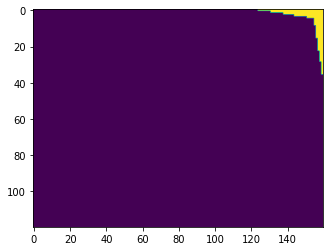

In [39]:
plt.imshow(thresh)

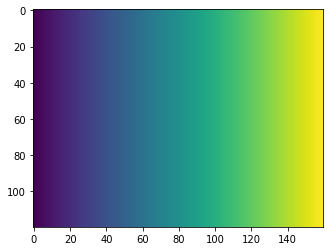

In [8]:
plt.imshow(x_mat)
plt.show()

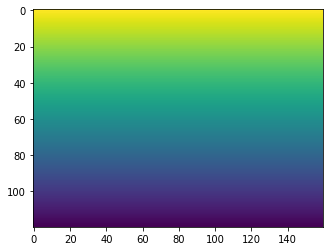

In [11]:
plt.imshow(y_mat)
plt.show()

In [15]:
%timeit u_d_vector(thresh)

91.7 µs ± 1.92 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [5]:
print(u_d_vector(thresh))

(14268.0, 22448.0)


In [49]:
def d_vector(masked_img, h_scaled_v = None, w_scaled_v = None, scaled_m = None):
	masked_img = masked_img.astype(float)
	if scaled_m is None:
		if h_scaled_v is None:
			raise ValueError()
		masked_img *= h_scaled_v
		if w_scaled_v:
			masked_img *= w_scaled_v
	else: 
		masked_img *= scaled_m

	xs = np.sum(masked_img, axis = 0)
	ys = np.sum(masked_img, axis = 1)
	# ys = ys[::-1]
	x, y = 0, 0
	for index, i in enumerate(xs):
		if i:
			x += index - len(xs)/2
	for index, j in enumerate(ys):
		if j:
			y += len(ys) - index
	return (x, y)

print(d_vector(thresh, h_scaled_v=scl_v))

(2214.0, 3690)


In [13]:
%timeit d_vector(thresh, h_scaled_v=scl_v)

127 µs ± 35.4 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [8]:
%timeit cv.bitwise_and(test, test, )

5.59 µs ± 676 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [4]:
%timeit cv.Canny(thresh, 100, 200)

109 µs ± 4.45 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [6]:
%timeit np.sum(test)

51 µs ± 14.4 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [63]:
frame_org = cv.imread("frame_l2.jpg")
t, thresh = cv.threshold(cv.cvtColor(frame_org, cv.COLOR_BGR2GRAY), 70, 255, cv.THRESH_BINARY_INV)
green = cv.inRange(cv.cvtColor(frame_org, cv.COLOR_BGR2HSV), boundaries["green"][0], boundaries["green"][1])
def n_green_square(g_frame, g_thresh):
	max_black = g_thresh.argmax(axis = 0)
	valid_cols = []
	prev_i = -1
	for i, col in enumerate(g_frame.transpose()):
		# print(valid_cols)
		if col[max_black[i]:].any(): # there is green beneath black
			if not (i - prev_i == 1 and prev_i >= 0):
				valid_cols.append([i])
			prev_i = i
		else:
			if (i - prev_i == 1 and prev_i >= 0):
				valid_cols[len(valid_cols)-1].append(i)
	if len(valid_cols[len(valid_cols)-1]) == 1:
		valid_cols[len(valid_cols)-1].append(prev_i)
	gs_list = list(filter(lambda xs: xs[1] - xs[0] > 30, valid_cols))
	if len(gs_list) == 1:
		black_M = cv.moments(thresh)
		black_cX = int(black_M["m10"] / black_M["m00"])
		mp = (gs_list[0][1] + gs_list[0][0])/2
		if mp > black_cX:
			return GreenSquare.RIGHT
		elif mp < black_cX:
			return GreenSquare.LEFT
	elif len(gs_list) == 2:
		return GreenSquare.LEFT
	else:
		return None

In [64]:
def n_green_square(g_frame, g_thresh):
	max_black = np.where(g_thresh.any(axis=0), g_thresh.argmax(axis=0), -1)
	valid_cols = []
	prev_i = -1
	for i, g_col in enumerate(g_frame.transpose()):
		if g_col.any():
			if g_col[max_black[i]:].any(): # there is green beneath black
				if not (i - prev_i == 1 and prev_i >= 0):
					valid_cols.append([i])
				prev_i = i
		else:
			if (i - prev_i == 1 and prev_i >= 0):
				valid_cols[len(valid_cols)-1].append(i)
	# if (g_frame.shape[1] - prev_i == 1 and prev_i >= 0):
	# 	valid_cols[len(valid_cols)-1].append(g_frame.shape[1] - 1)
	if len(valid_cols[len(valid_cols)-1]) == 1:
		valid_cols[len(valid_cols)-1].append(prev_i)
	# print(valid_cols)
	gs_list = list(filter(lambda xs: xs[1] - xs[0] > 15, valid_cols))
	if len(gs_list) == 1:
		black_M = cv.moments(thresh)
		# if np.sum(thresh) == 0:
		# 	return None
		black_cX = int(black_M["m10"] / black_M["m00"])
		mp = (gs_list[0][1] + gs_list[0][0])/2
		if mp > black_cX:
			return GreenSquare.RIGHT
		elif mp < black_cX:
			return GreenSquare.LEFT
	elif len(gs_list) == 2:
		return GreenSquare.LEFT
	else:
		return None

In [67]:
n_green_square(green, thresh)

<GreenSquare.LEFT: 2>

In [31]:
%timeit np.where(thresh.any(axis=0), thresh.argmax(axis=0), -1)

93.2 µs ± 11 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [58]:
def h_line_filter(line):
	rho, theta = line[0]
	return theta <= math.pi/2 + epsilon and theta >= math.pi/2 - epsilon
	
def y_value(line, x_value):
	rho, theta = line[0]
	return (rho - x_value*math.cos(theta))/(math.sin(theta))

def green_square(g_frame, thresh):
	edges = cv.Canny(thresh, 100, 200)
	lines = cv.HoughLines(edges,1,np.pi/180,gs_voting)
	if g_frame.shape[1] != thresh.shape[1]:
		raise ValueError()
	if lines is None:
		return
	f_lines = list(filter(h_line_filter, lines))
	width = g_frame.shape[1]
	if len(f_lines) > 0:
		y_intercepts = [int(y_value(line, 0)) for line in f_lines]
		width_intercepts = [int(y_value(line, width)) for line in f_lines]

		mask = np.ones(g_frame.shape[:2], dtype=np.uint8)
		useless_pixels = np.array([
			[0, 0], 
			[width, 0], 
			[width, max(width_intercepts)],
			[0, max(y_intercepts)]
		])
		cv.fillPoly(mask, pts =[useless_pixels], color=0)
		# get mask for region beneath black line

		roi = cv.bitwise_and(g_frame, g_frame, mask=mask) # get region below black line
		contours,hierarchy = cv.findContours(roi, 1, 2)

		# green_vector = d_vector(roi, h_scaled_v=gs_scaled_v) # which side of the frame the green is on

		black_M = cv.moments(thresh)
		black_cX = int(black_M["m10"] / black_M["m00"])

		# Cropping isn't perfect and some green still remains on the screen
		# this is to prevent the "specks" of green to count as a green square
		f_contours = list(filter(lambda cnt: cv.contourArea(cnt) > min_area, contours))
		# print(black_cX)
		if len(f_contours) == 2:
			return GreenSquare.DOUBLE
		elif len(f_contours) == 1:
			green_M = cv.moments(f_contours[0])
			green_cX = int(green_M["m10"] / green_M["m00"])
			if green_cX > black_cX:
				return GreenSquare.RIGHT
			elif green_cX < black_cX:
				return GreenSquare.LEFT

In [59]:
%timeit green_square(green, thresh)

3.78 ms ± 53.9 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [16]:
v_close = cv.imread("silver/f1.jpeg")
n_close = cv.imread("silver/f2.jpeg")
far = cv.imread("silver/f5.jpeg")
gray_v = cv.cvtColor(v_close, cv.COLOR_BGR2GRAY)
gray_n = cv.cvtColor(n_close, cv.COLOR_BGR2GRAY)
gray_f = cv.cvtColor(far, cv.COLOR_BGR2GRAY)
t, thresh_v = cv.threshold(cv.cvtColor(v_close, cv.COLOR_BGR2GRAY), 70, 255, cv.THRESH_BINARY_INV)
t, thresh_n = cv.threshold(cv.cvtColor(n_close, cv.COLOR_BGR2GRAY), 70, 255, cv.THRESH_BINARY_INV)
t, thresh_f = cv.threshold(cv.cvtColor(far, cv.COLOR_BGR2GRAY), 70, 255, cv.THRESH_BINARY_INV)

In [22]:
empty_index_f,  = np.where(np.sum(thresh_f, axis=1) == 0)
bl_index_f = max(empty_index_f)	if empty_index_f.size > 0 else 0

empty_index_v,  = np.where(np.sum(thresh_v, axis=1) == 0)
bl_index_v = max(empty_index_v)	if empty_index_v.size > 0 else 0

In [40]:
normalized_var(gray_n, get_black_endpoint(thresh_n), 12)

NameError: name 'get_black_endpoint' is not defined

In [39]:
mean, stddev = cv.meanStdDev(roi)
stddev[0][0] ** 2/mean[0][0]

8.676819002456778